#**Travaux Pratiques : Préparation des Données**
### **Objectif**
Appliquer des techniques de préparation des données sur un jeu de données réel lié aux services de transport. Ces techniques incluent le nettoyage, la transformation, la gestion des valeurs manquantes et la création de nouvelles caractéristiques.

### **Dataset Utilisé**
Le jeu de données contient des informations sur les courses Uber, y compris les caractéristiques des trajets, comme la date et l'heure, les coordonnées de prise en charge et de dépose, ainsi que le nombre de passagers. Ce jeu de données est utilisé pour prédire le montant des courses (fare amount) et identifier d'éventuelles anomalies ou tendances dans le service.

**Imporeter les bibliothèques necessiares**

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Charger le dataset**

In [181]:
df = pd.read_csv('datauber.csv')
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0
...,...,...,...,...,...,...,...,...,...
44372,35522961.0,2013-09-28 01:30:18.0000001,21.5,2013-09-28 01:30:18 UTC,-73.989875,40.719197,-73.979169,40.780914,1.0
44373,34717029.0,2014-03-28 19:28:34.0000005,5.0,2014-03-28 19:28:34 UTC,-73.994805,40.740033,-74.003328,40.732565,1.0
44374,51028248.0,2011-03-30 12:54:23.0000005,9.3,2011-03-30 12:54:23 UTC,-73.982996,40.726833,-74.005368,40.733291,2.0
44375,50834096.0,NaN,4.9,2011-11-07 22:59:56 UTC,-73.958802,40.810530,-73.945712,40.812308,1.0


**Exploration et aperçu des Données**

In [182]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [183]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0


In [184]:
df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
44372,35522961.0,2013-09-28 01:30:18.0000001,21.5,2013-09-28 01:30:18 UTC,-73.989875,40.719197,-73.979169,40.780914,1.0
44373,34717029.0,2014-03-28 19:28:34.0000005,5.0,2014-03-28 19:28:34 UTC,-73.994805,40.740033,-74.003328,40.732565,1.0
44374,51028248.0,2011-03-30 12:54:23.0000005,9.3,2011-03-30 12:54:23 UTC,-73.982996,40.726833,-74.005368,40.733291,2.0
44375,50834096.0,NaN,4.9,2011-11-07 22:59:56 UTC,-73.958802,40.810530,-73.945712,40.812308,1.0
44376,15145716.0,2012-07-12 00:59:02.0000002,3.3,2012-07-12 00:59:02 UTC,-73.982371,40.765501,-73.985248,40.762808,1.0


In [185]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,4.224300e+04,42217.000000,42183.000000,42130.000000,42183.000000,42119.000000,42159.000000
mean,2.767290e+07,11.409233,-72.568666,39.948790,-72.588555,39.957229,1.677720
std,1.602678e+07,10.091979,10.776933,6.006307,10.684628,5.962407,1.296484
min,4.800000e+01,0.000000,-748.016667,-74.015515,-737.916665,-74.008745,0.000000
25%,1.372484e+07,6.000000,-73.992075,40.734808,-73.991496,40.733766,1.000000
50%,2.765192e+07,8.500000,-73.981857,40.752503,-73.980170,40.752910,1.000000
75%,4.151020e+07,12.600000,-73.967187,40.767077,-73.963738,40.768162,2.000000
max,5.542169e+07,350.000000,40.774042,45.031653,40.828377,45.031598,6.000000


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44377 entries, 0 to 44376
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42243 non-null  float64
 1   key                42143 non-null  object 
 2   fare_amount        42217 non-null  float64
 3   pickup_datetime    42094 non-null  object 
 4   pickup_longitude   42183 non-null  float64
 5   pickup_latitude    42130 non-null  float64
 6   dropoff_longitude  42183 non-null  float64
 7   dropoff_latitude   42119 non-null  float64
 8   passenger_count    42159 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.0+ MB


# **Partie 1: Nettoyage de données**

### **Gestion des doublons**


1- Detection des doublons

In [187]:
print("Nombre de doublons:", df.duplicated().sum())

Nombre de doublons: 105


2-Suppression des doublons


In [188]:
df.drop_duplicates(inplace=True)

3-Vérification après la suppresion des doublons

In [189]:
print("Nombre de doublons:", df.duplicated().sum())

Nombre de doublons: 0


## **Gestion des valeurs manquantes**

Affichage du nombre de valeurs manquantes par *colonne*


In [190]:
print("Valeurs manquantes:", df.isnull().sum())

Valeurs manquantes: Unnamed: 0           2129
key                  2232
fare_amount          2158
pickup_datetime      2277
pickup_longitude     2189
pickup_latitude      2238
dropoff_longitude    2188
dropoff_latitude     2250
passenger_count      2212
dtype: int64


Suppression des lignes avec des valeurs manquantes

In [191]:
df.dropna(inplace=True)


Affichage du nombre de valeurs manquantes restantes

In [192]:
print("Valeurs manquantes:", df.isnull().sum())

Valeurs manquantes: Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


Visualisation des valeurs manquantes avec un heatmap

<Axes: >

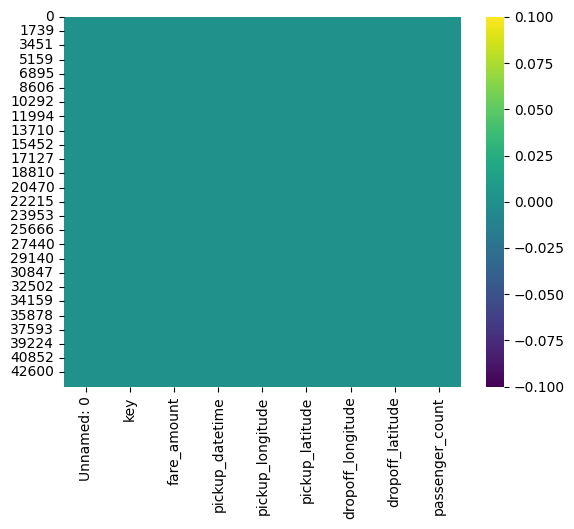

In [193]:
#any null value will be visible (distinct)
sns.heatmap(df.isnull(), cmap = 'viridis')

Visualisation des données à l'aide d'histogrammes

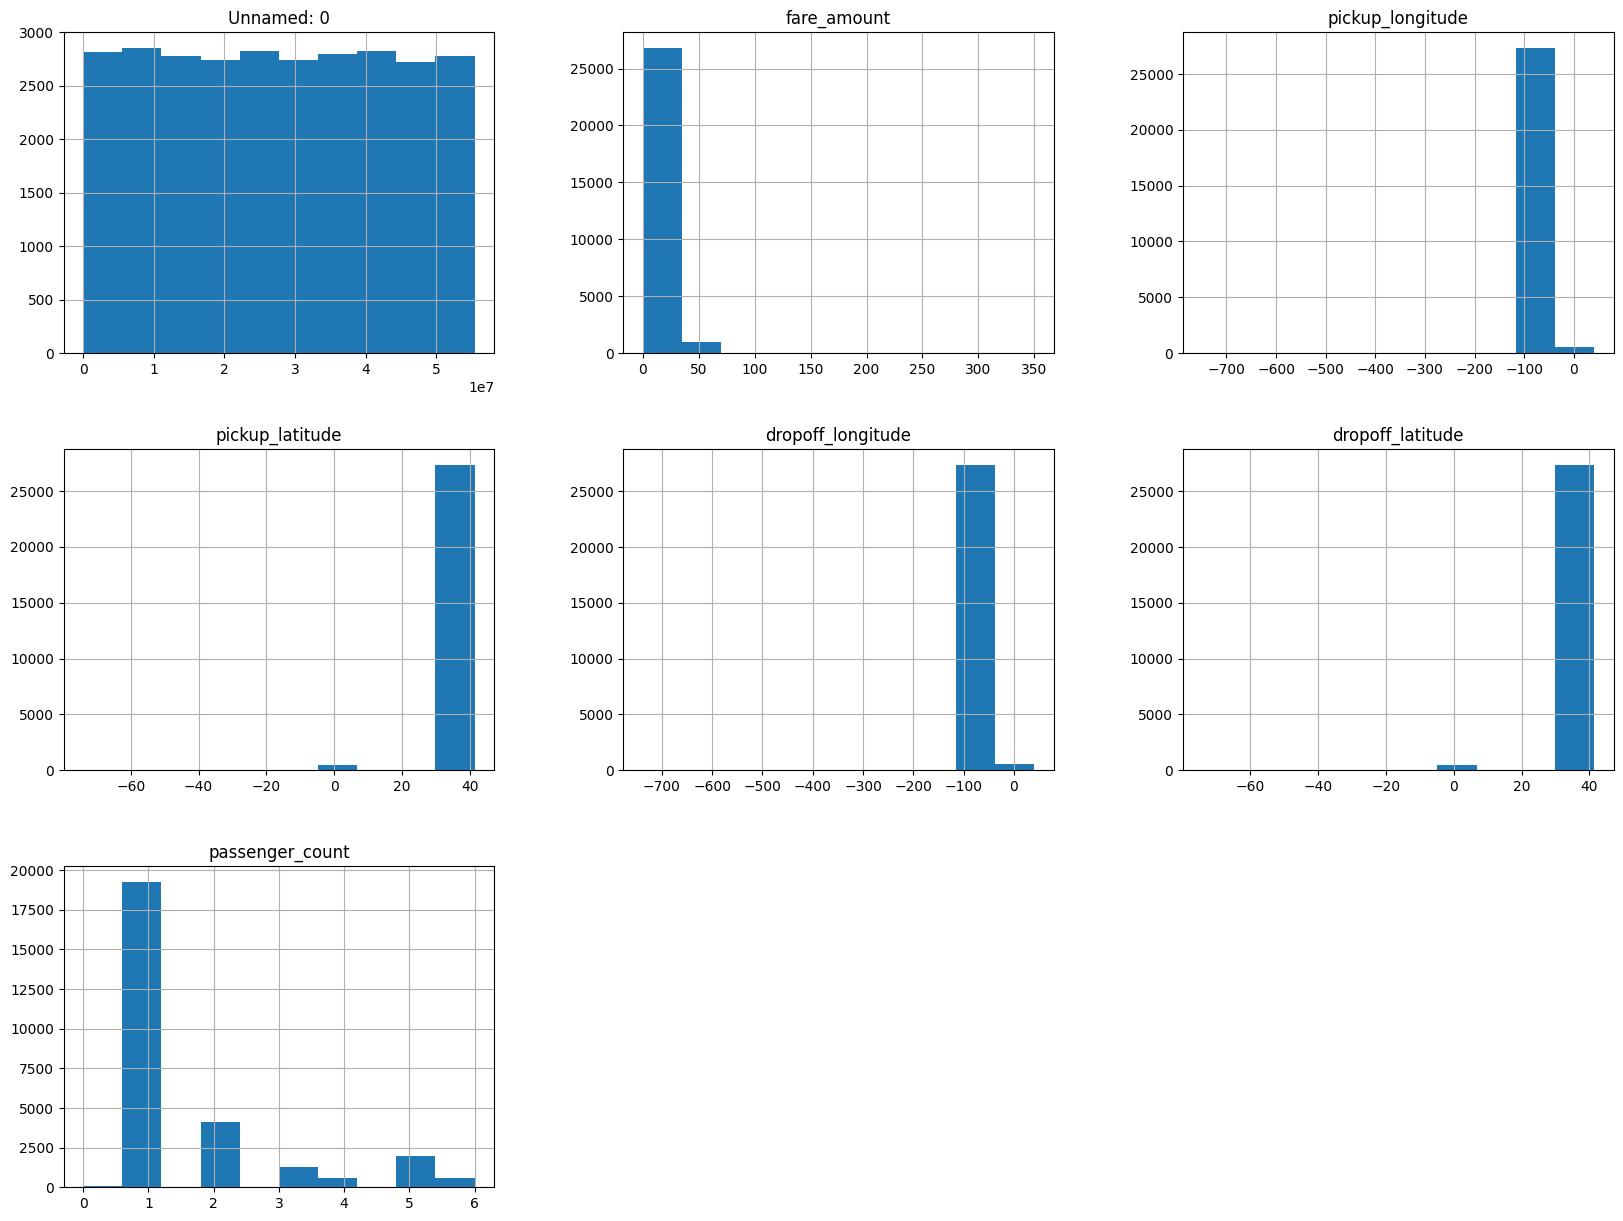

In [194]:
df.hist(figsize=(20,15))
plt.show()

### **Partie 2: Transformation de données**

**Encodage de la variable defects**


In [195]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger le DataFrame
df = pd.read_csv('datauber.csv')

# Encodage des variables catégorielles
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("\nDataset après encodage des variables catégorielles :")
print(df.head())

# Encodage de la variable cible
target = 'defects'  # Remplacez par le nom exact de la variable cible
if target in df.columns:
    # Vérifiez les valeurs manquantes
    if df[target].isnull().sum() > 0:
        print(f"\nErreur : la cible '{target}' contient des valeurs manquantes.")
    else:
        target_encoder = LabelEncoder()
        df[target] = target_encoder.fit_transform(df[target])
        print("\nCible encodée :")
        print(df[[target]].head())
else:
    print(f"\nErreur : la cible '{target}' n'est pas dans le dataset.")


Dataset après encodage des variables catégorielles :
   Unnamed: 0    key  fare_amount  pickup_datetime  pickup_longitude  \
0  24238194.0  41165          7.5            40968        -73.999817   
1  27835199.0   3492          7.7             3467        -73.994355   
2  44984355.0   4140         12.9            41842        -74.005043   
3  25894730.0   3156          5.3             3128        -73.976124   
4  17610152.0  36954         16.0            36749               NaN   

   pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  
0        40.738354         -73.999512         40.723217              1.0  
1        40.728225         -73.994710         40.750325              1.0  
2        40.740770                NaN         40.772647              1.0  
3              NaN         -73.965316         40.803349              3.0  
4        40.744085         -73.973082               NaN              5.0  

Erreur : la cible 'defects' n'est pas dans le dataset.


**Normalisation**

In [196]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Normalisation des données avant la matrice de corrélation
scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[df.select_dtypes(include=[np.number]).columns] = scaler.fit_transform(df[df.select_dtypes(include=[np.number]).columns])


Convert Data Types

In [197]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


# Feature Engineering

In [198]:
df['pickup_hour']= df['pickup_datetime'].dt.hour
df['pickup_day']= df['pickup_datetime'].dt.day
df['pickup_month']= df['pickup_datetime'].dt.month

# Data Visualization


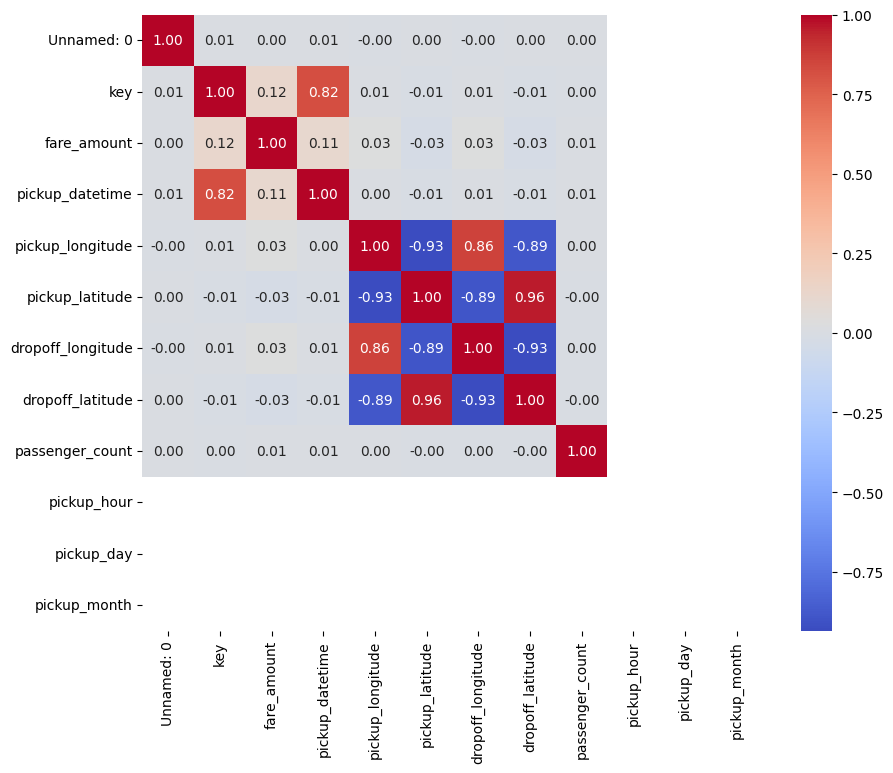

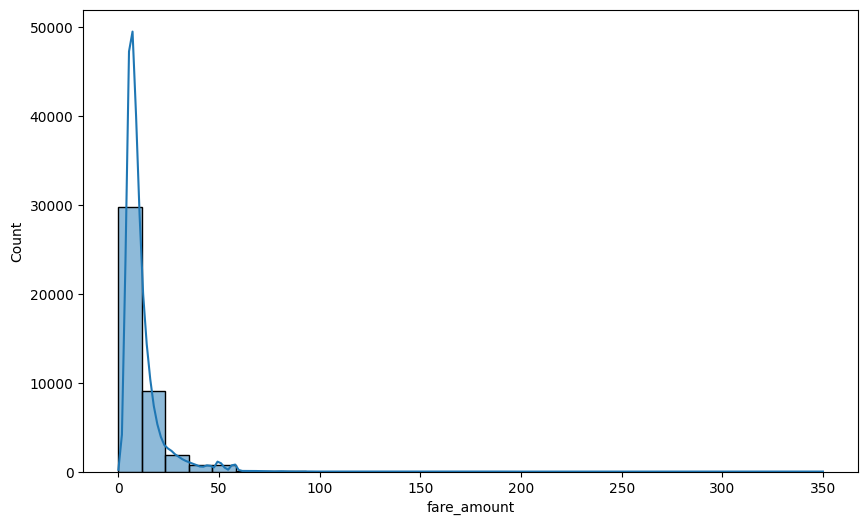

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# Distribution of fare_amount
plt.figure(figsize=(10, 6))
sns.histplot(df['fare_amount'], bins=30, kde=True)
plt.show()

# RandomForest !!

Missing values before imputation:
 pickup_day         2169
pickup_hour        2169
pickup_minute      2169
passenger_count    2122
dtype: int64
Missing values after imputation:
 pickup_day         0
pickup_hour        0
pickup_minute      0
passenger_count    0
dtype: int64
Feature Importances: [0.05250344 0.08991761 0.11257286 0.04094508 0.00823256 0.69582844]
MSE: 52.10032740296323
R²: 0.5218378349808941


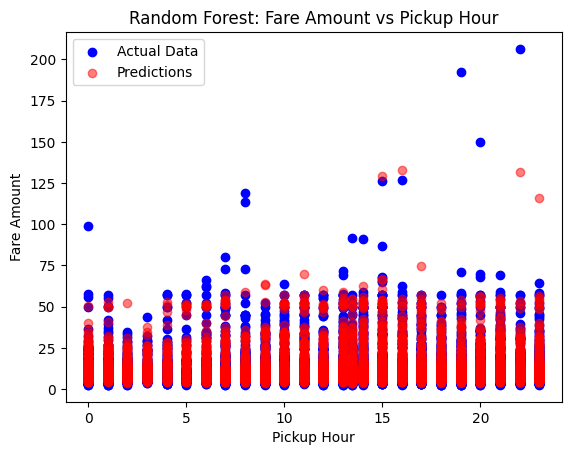

In [200]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load the data
df = pd.read_csv('datauber.csv')

# Data Cleaning
df.dropna(subset=['fare_amount'], inplace=True)  # Ensure fare_amount has no missing values
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')  # Convert to datetime

# Feature Engineering: Extract day, hour, and minute
df['pickup_day'] = df['pickup_datetime'].dt.dayofweek
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_minute'] = df['pickup_datetime'].dt.minute
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)

# Calculate distance between pickup and dropoff using the basic formula
def calculate_distance(row):
    # Convert degrees to radians
    lat1, lon1 = np.radians(row['pickup_latitude']), np.radians(row['pickup_longitude'])
    lat2, lon2 = np.radians(row['dropoff_latitude']), np.radians(row['dropoff_longitude'])
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of Earth in kilometers
    return c * r

# Assuming pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude are in df
df['distance_km'] = df.apply(calculate_distance, axis=1)

# Check for missing values in features
print("Missing values before imputation:\n", df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count']].isnull().sum())

# Impute missing values
imputer = SimpleImputer(strategy='mean')
df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count']] = imputer.fit_transform(
    df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count']]
)

# Check for missing values after imputation
print("Missing values after imputation:\n", df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count']].isnull().sum())

# Selecting features and target
X = df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend', 'distance_km']]  # Independent variables
y = df['fare_amount']  # Dependent variable

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Feature Importances:", model.feature_importances_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Visualization (if needed)
plt.scatter(X_test['pickup_hour'], y_test, color="blue", label="Actual Data")
plt.scatter(X_test['pickup_hour'], y_pred, color="red", label="Predictions", alpha=0.5)
plt.xlabel("Pickup Hour")
plt.ylabel("Fare Amount")
plt.title("Random Forest: Fare Amount vs Pickup Hour")
plt.legend()
plt.show()

# Linear Regression

Missing values after imputation:
 pickup_day         0
pickup_hour        0
pickup_minute      0
passenger_count    0
distance_km        0
dtype: int64
MSE: 108.97123461660196
R²: -0.00010737103574842699


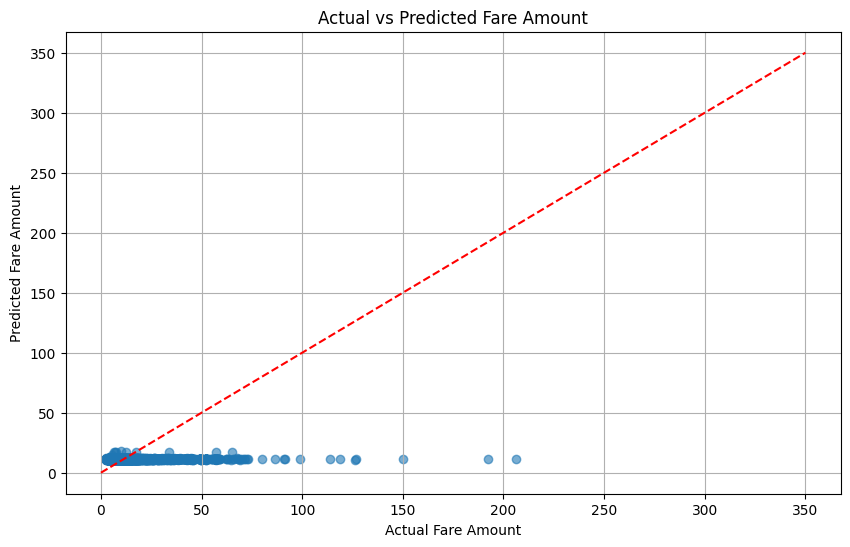

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Load the data
df = pd.read_csv('datauber.csv')

# Data Cleaning
df.dropna(subset=['fare_amount'], inplace=True)  # Ensure fare_amount has no missing values
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')  # Convert to datetime

# Feature Engineering: Extract day, hour, and minute
df['pickup_day'] = df['pickup_datetime'].dt.dayofweek
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_minute'] = df['pickup_datetime'].dt.minute
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)

# Create distance function and add distance feature
def calculate_distance(row):
    lat1, lon1 = np.radians(row['pickup_latitude']), np.radians(row['pickup_longitude'])
    lat2, lon2 = np.radians(row['dropoff_latitude']), np.radians(row['dropoff_longitude'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of Earth in kilometers
    return c * r

df['distance_km'] = df.apply(calculate_distance, axis=1)

# Impute missing values for features of interest
imputer = SimpleImputer(strategy='mean')
features_to_impute = ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'distance_km']
df[features_to_impute] = imputer.fit_transform(df[features_to_impute])

# Check for remaining NaN values
print("Missing values after imputation:\n", df[features_to_impute].isnull().sum())

# Selecting features and target
X = df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend', 'distance_km']]
y = df['fare_amount']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline for imputation and modeling
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LinearRegression())
])

# Fit the model using the pipeline
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted Fare Amount")
plt.grid()
plt.show()

In [202]:
import pandas as pd

def calculate_average_fare(file_path):
    """
    Reads the fare_amount column from the specified CSV file and calculates its average.

    Parameters:
    - file_path: str, path to the CSV file containing the dataset.

    Returns:
    - average_fare: float, the average fare_amount.
    """
    # Load the data
    df = pd.read_csv(file_path)

    # Check if 'fare_amount' column exists
    if 'fare_amount' not in df.columns:
        raise ValueError("The column 'fare_amount' does not exist in the dataset.")

    # Calculate the average fare_amount
    average_fare = df['fare_amount'].mean()

    return average_fare

# Example usage
file_path = 'datauber.csv'
average_fare = calculate_average_fare(file_path)
print("Average Fare Amount:", average_fare)

Average Fare Amount: 11.409232536655848
